In [44]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import os
import zipfile
from PIL import Image
import numpy as np

In [15]:
import io
import requests

def load_images_from_zip(zip_file):
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        images = {'anastasia': [], 'takao': []}
        for file_name in zip_ref.namelist():
            if file_name.startswith('anastasia') and file_name.endswith('.jpg'):
                with zip_ref.open(file_name) as file:
                    img = Image.open(file).convert('RGB')
                    images['anastasia'].append(np.array(img))
            elif file_name.startswith('takao') and file_name.endswith('.jpg'):
                with zip_ref.open(file_name) as file:
                    img = Image.open(file).convert('RGB')
                    images['takao'].append(np.array(img))
    return images

zip_file_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/xZQHOyN8ONT92kH-ASb4Pw/data.zip'

# Download the ZIP file
response = requests.get(zip_file_url)
zip_file_bytes = io.BytesIO(response.content)

# Load images from zip file
images = load_images_from_zip(zip_file_bytes)

In [16]:
print(f"{len(images['anastasia'])}")
print(f"{len(images['takao'])}")

50
50


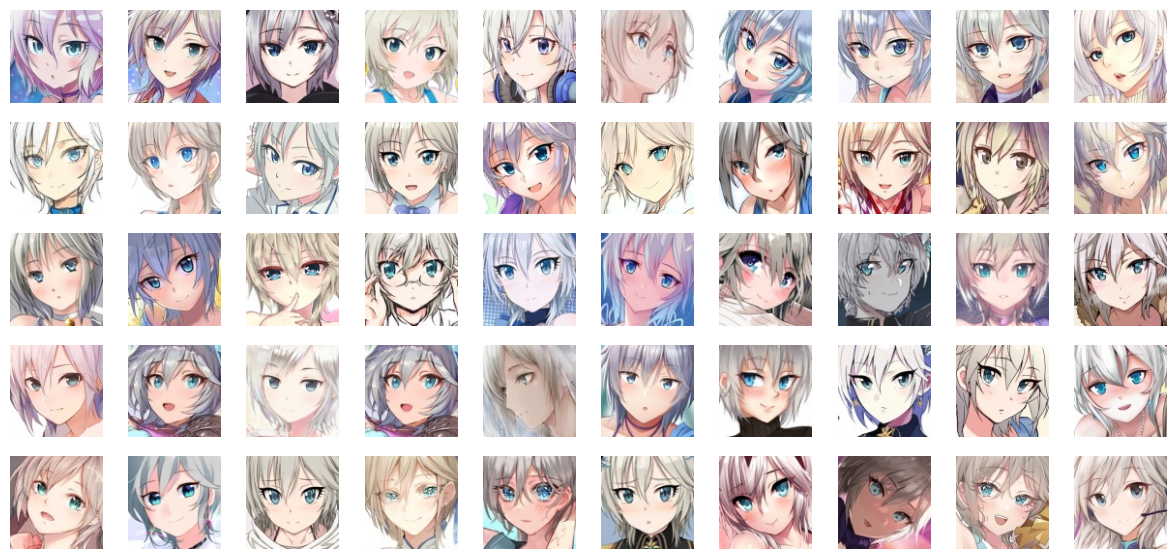

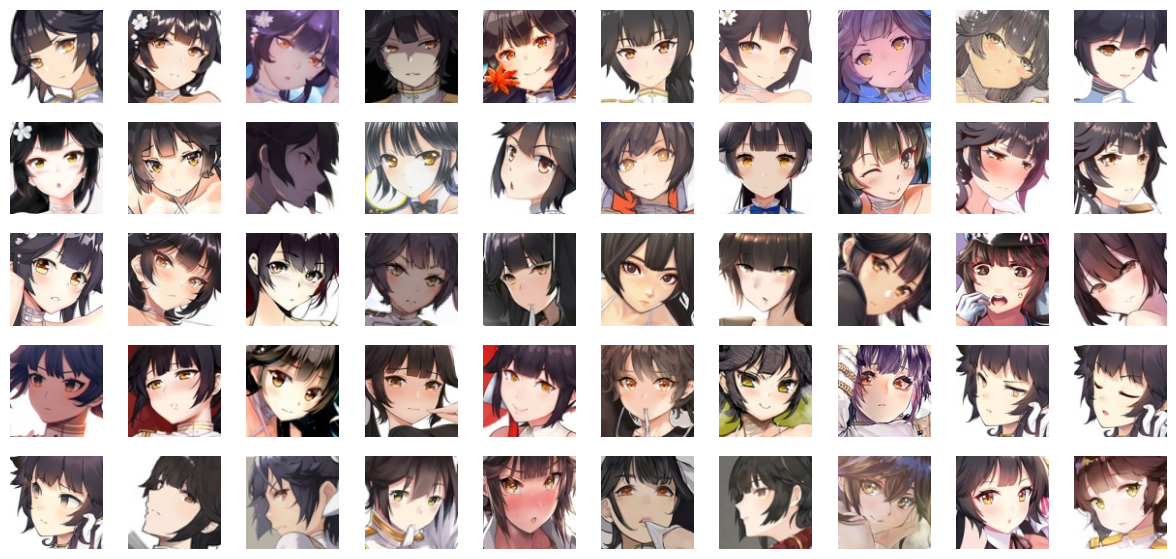

In [25]:
def plot_images(images):
    plt.figure(figsize=(15, 7))
    for i, image in enumerate(images):
        plt.subplot(5, 10, i + 1)
        plt.imshow(image)
        plt.axis('off')
    plt.show()
plot_images(images['anastasia'])
plot_images(images['takao'])


In [26]:
class AnimeDataset(Dataset):
    def __init__(self, images, transform=None, classes=None):
        self.images = []
        self.labels = []
        self.transform = transform
        self.classes = classes

        for label, class_name in enumerate(self.classes):
            for image in images[class_name]:
                self.images.append(image)
                self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image = Image.fromarray(self.images[index])
        label = self.labels[index]

        if self.transform:
            image = self.transform(image)

        return image, label

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset = AnimeDataset(images, transform=transform, classes=['anastasia', 'takao'])

In [31]:
dataset[0][1]

0

In [32]:
len(dataset)

100

In [43]:
train_size = int(0.8 * len(dataset))
validation_size = len(dataset) - train_size
train_dataset, validation_dataset = random_split(dataset, [train_size, validation_size])

print(len(train_dataset))
print(len(validation_dataset))

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=20, shuffle=False)


80
20


In [50]:
class AnimeCNN(nn.Module):
    def __init__(self):
        super(AnimeCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 2, 1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 16 * 16)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = AnimeCNN()

In [51]:
print(model)

AnimeCNN(
  (conv1): Conv2d(3, 32, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)


In [53]:
list(model.children())

[Conv2d(3, 32, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1)),
 Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
 MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False),
 Linear(in_features=16384, out_features=128, bias=True),
 Linear(in_features=128, out_features=2, bias=True)]

In [54]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [59]:
num_epochs = 10
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for i, data in enumerate(train_loader, 0):
        inputs, labels = data
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for data in validation_loader:
            inputs, labels = data
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    val_loss = val_loss / len(validation_loader)
    val_losses.append(val_loss)

    print(f'Epoch {epoch + 1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

print('Finished Training')

Epoch 1, Train Loss: 0.0000, Val Loss: 1.2232
Epoch 2, Train Loss: 0.0000, Val Loss: 1.2250
Epoch 3, Train Loss: 0.0000, Val Loss: 1.2277
Epoch 4, Train Loss: 0.0000, Val Loss: 1.2300
Epoch 5, Train Loss: 0.0000, Val Loss: 1.2316
Epoch 6, Train Loss: 0.0000, Val Loss: 1.2329
Epoch 7, Train Loss: 0.0000, Val Loss: 1.2343
Epoch 8, Train Loss: 0.0000, Val Loss: 1.2359
Epoch 9, Train Loss: 0.0000, Val Loss: 1.2377
Epoch 10, Train Loss: 0.0000, Val Loss: 1.2393
Finished Training


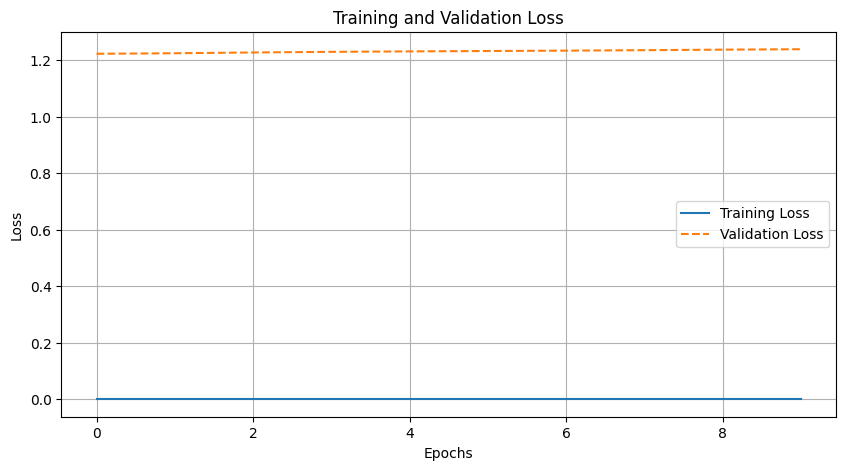

In [60]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.title('Training and Validation Loss')
plt.show()

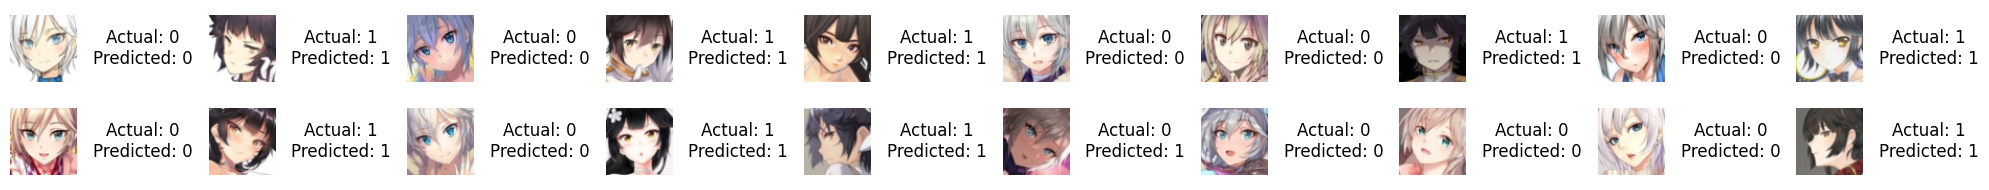

In [62]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Function to display an image
def imshow(img, ax):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    ax.imshow(np.transpose(npimg, (1, 2, 0)))  # Transpose dimensions to match matplotlib's expected format
    ax.axis('off')

# Set model to evaluation mode
model.eval()

data_iter = iter(validation_loader)
images, labels = next(data_iter)
outputs = model(images)
_, predicted = torch.max(outputs, 1)

# Define the grid size
num_images = len(images)
num_cols = 10
num_rows = 2

fig, axs = plt.subplots(num_rows, num_cols * 2, figsize=(20, num_rows))

for idx in range(num_images):
    row = idx // num_cols
    col = (idx % num_cols) * 2

    # Plot the image
    imshow(images[idx].cpu(), axs[row, col])

    # Display actual and predicted labels
    axs[row, col + 1].text(0.5, 0.5, f"Actual: {labels[idx].item()}\nPredicted: {predicted[idx].item()}",
                           horizontalalignment='center', verticalalignment='center', fontsize=12)
    axs[row, col + 1].axis('off')

# Turn off any remaining empty subplots
for idx in range(num_images, num_rows * num_cols):
    row = idx // num_cols
    col = (idx % num_cols) * 2
    axs[row, col].axis('off')
    axs[row, col + 1].axis('off')

plt.tight_layout()
plt.show()

In [63]:
correct = 0
total = 0

# Compute overall accuracy
with torch.no_grad():
    for data in validation_loader:
        images, labels = data
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        print(f'correct: {correct}, total: {total}')

print(f'Validation Accuracy: {100 * correct / total:.2f}%')

correct: 19, total: 20
Validation Accuracy: 95.00%


In [64]:
class AnimeCNNModified(nn.Module):
    def __init__(self):
        super(AnimeCNNModified, self).__init__()
        # Add padding=1 to maintain the border
        self.conv1 = nn.Conv2d(3, 32, 3, 1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.pool(F.leaky_relu(self.conv1(x)))  # Change activation function here
        x = self.pool(F.leaky_relu(self.conv2(x)))  # Change activation function here
        x = x.view(-1, 64 * 16 * 16)
        x = F.relu(self.fc1(x))  # Change activation function here
        x = self.fc2(x)
        return x

Epoch 1, Train Loss: 0.5992, Val Loss: 0.1846
Epoch 2, Train Loss: 0.0284, Val Loss: 0.4557
Epoch 3, Train Loss: 0.0801, Val Loss: 0.8318
Epoch 4, Train Loss: 0.0021, Val Loss: 0.5236
Epoch 5, Train Loss: 0.0588, Val Loss: 0.6774
Epoch 6, Train Loss: 0.0000, Val Loss: 0.8907
Epoch 7, Train Loss: 0.0008, Val Loss: 0.9811
Epoch 8, Train Loss: 0.0005, Val Loss: 0.9880
Epoch 9, Train Loss: 0.0002, Val Loss: 0.9768
Epoch 10, Train Loss: 0.0001, Val Loss: 0.9636
Epoch 11, Train Loss: 0.0001, Val Loss: 0.9534
Epoch 12, Train Loss: 0.0000, Val Loss: 0.9482
Epoch 13, Train Loss: 0.0000, Val Loss: 0.9428
Epoch 14, Train Loss: 0.0000, Val Loss: 0.9402
Epoch 15, Train Loss: 0.0000, Val Loss: 0.9369
Epoch 16, Train Loss: 0.0000, Val Loss: 0.9353
Epoch 17, Train Loss: 0.0000, Val Loss: 0.9337
Epoch 18, Train Loss: 0.0000, Val Loss: 0.9326
Epoch 19, Train Loss: 0.0000, Val Loss: 0.9320
Epoch 20, Train Loss: 0.0000, Val Loss: 0.9307
Finished Training


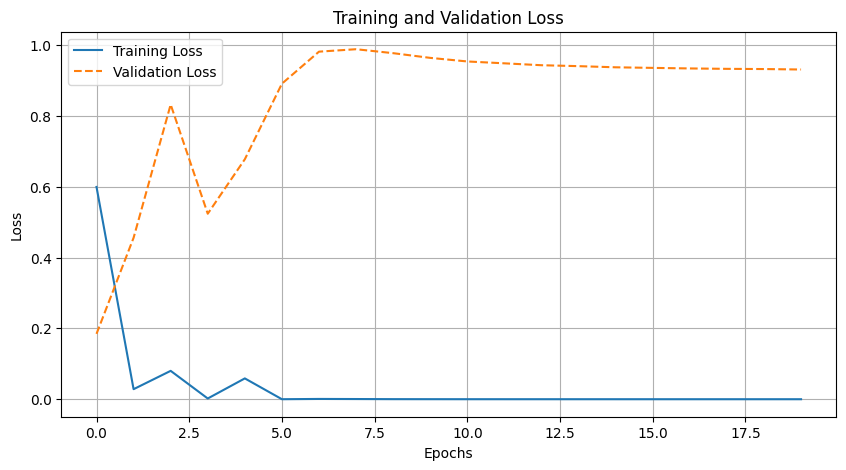

In [66]:
# Instantiate the model
model_new = AnimeCNN()

import torch.optim as optim

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_new.parameters(), lr=0.001)

import matplotlib.pyplot as plt
import torch

# Training loop
# TODO: Increase the number of epochs
num_epochs = 20 # Increase the number of epochs here
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model_new.train()
    running_loss = 0.0
    for i, data in enumerate(train_loader, 0):
        inputs, labels = data
        optimizer.zero_grad()
        outputs = model_new(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    model_new.eval()
    val_loss = 0.0
    with torch.no_grad():
        for data in validation_loader:
            inputs, labels = data
            outputs = model_new(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    val_loss = val_loss / len(validation_loader)
    val_losses.append(val_loss)

    print(f'Epoch {epoch + 1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

print('Finished Training')

# Plotting the training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.title('Training and Validation Loss')
plt.show()